Data Preprocessing

Taking raw video frames, finding every face in them, aligning them consistently, and saving clean 224×224 crops. The CNN later sees only these crops

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("xdxd003/ff-c23")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ff-c23' dataset.
Path to dataset files: /kaggle/input/ff-c23


In [2]:
import os

# Step 1: confirm the actual path
print("=== DATASET ROOT ===")
print(path)
print()

# Step 2: walk the full structure (4 levels deep)
print("=== FOLDER STRUCTURE ===")
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth > 4:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    # Show a few sample filenames at the deepest level
    if files:
        sample = files[:3]
        for f in sample:
            print(f"{'  ' * (depth+1)}{f}")
        if len(files) > 3:
            print(f"{'  ' * (depth+1)}... ({len(files)} total files)")

=== DATASET ROOT ===
/kaggle/input/ff-c23

=== FOLDER STRUCTURE ===
ff-c23/
  FaceForensics++_C23/
    Face2Face/
      479_706.mp4
      481_469.mp4
      184_205.mp4
      ... (1000 total files)
    csv/
      FaceSwap.csv
      FaceShifter.csv
      DeepFakeDetection.csv
      ... (10 total files)
    Deepfakes/
      479_706.mp4
      481_469.mp4
      184_205.mp4
      ... (1000 total files)
    DeepFakeDetection/
      02_09__kitchen_pan__9TDCEK1Q.mp4
      02_13__exit_phone_room__CP5HFV3K.mp4
      24_10__walking_down_street_outside_angry__356HPS7R.mp4
      ... (1000 total files)
    original/
      123.mp4
      738.mp4
      479.mp4
      ... (1000 total files)
    NeuralTextures/
      479_706.mp4
      481_469.mp4
      184_205.mp4
      ... (1000 total files)
    FaceShifter/
      479_706.mp4
      481_469.mp4
      184_205.mp4
      ... (1000 total files)
    FaceSwap/
      479_706.mp4
      481_469.mp4
      184_205.mp4
      ... (1000 total files)


In [3]:
import os

path = "/root/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1"  # typical kagglehub path

# Walk the top 3 levels to understand structure
for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth > 3:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/")
    if depth == 3:
        print(f"{'  ' * (depth+1)}... {len(files)} files")

In [5]:
from pathlib import Path
import os

BASE = "/kaggle/input/ff-c23/FaceForensics++_C23"

REAL_VIDEOS = os.path.join(BASE, "original")
FAKE_VIDEOS = os.path.join(BASE, "Deepfakes")

OUTPUT_DIR = "/kaggle/working/face_crops"
REAL_OUT   = os.path.join(OUTPUT_DIR, "real")
FAKE_OUT   = os.path.join(OUTPUT_DIR, "fake")

os.makedirs(REAL_OUT, exist_ok=True)
os.makedirs(FAKE_OUT, exist_ok=True)

# Sanity check
print("Real videos:", len(list(Path(REAL_VIDEOS).glob("*.mp4"))))
print("Fake videos:", len(list(Path(FAKE_VIDEOS).glob("*.mp4"))))

Real videos: 1000
Fake videos: 1000


In [ ]:
pip install torch torchvision facenet-pytorch opencv-python

  Using cached pillow-10.2.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (9.7 kB)
INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 18.7 MB/s  0:00:00
  Attempting uninstall: facenet-pytorch
    Found existing installation: facenet-pytorch 2.6.0
    Uninstalling facenet-pytorch-2.6.0:
      Successfully uninstalled facenet-pytorch-2.6.0


: 

In [15]:
# Force a compatible Pillow + torchvision combination (and optionally torch)
!pip install -U pip
!pip install pillow==10.0.0 torchvision==0.24.1 torch==2.9.1

import os
os.kill(os.getpid(), 9)  # restart runtime (Colab style)

: 

: 

In [6]:
import cv2
import numpy as np
import torch
from facenet_pytorch import MTCNN
from torchvision import transforms
from pathlib import Path

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using: {device}")

mtcnn = MTCNN(
    keep_all=False,
    select_largest=True,
    min_face_size=60,        # ignore tiny background faces
    device=device
)

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def align_face(image, landmarks):
    left_eye  = landmarks[0]
    right_eye = landmarks[1]
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))
    center = (
        int((left_eye[0] + right_eye[0]) / 2),
        int((left_eye[1] + right_eye[1]) / 2)
    )
    M = cv2.getRotationMatrix2D(center, angle, scale=1.0)
    return cv2.warpAffine(image, M, (image.shape[1], image.shape[0]))

def crop_with_margin(image, box, margin=0.3):
    x1, y1, x2, y2 = [int(v) for v in box]
    w, h = x2 - x1, y2 - y1
    x1 = max(0, x1 - int(w * margin))
    y1 = max(0, y1 - int(h * margin))
    x2 = min(image.shape[1], x2 + int(w * margin))
    y2 = min(image.shape[0], y2 + int(h * margin))
    crop = image[y1:y2, x1:x2]
    return crop if crop.size > 0 else None

Using: cuda


In [7]:
def process_videos(video_dir, output_dir, label, every_n=5, max_videos=None):
    video_files = sorted(Path(video_dir).glob("*.mp4"))
    if max_videos:
        video_files = video_files[:max_videos]

    total_crops = 0

    for vid_idx, video_path in enumerate(video_files):
        cap = cv2.VideoCapture(str(video_path))
        frame_idx, saved = 0, 0

        while True:
            ret, frame = cap.read()
            if not ret:
                break

            if frame_idx % every_n == 0:
                frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

                boxes, probs, landmarks = mtcnn.detect(frame_rgb, landmarks=True)

                # Skip if no face or low confidence
                if boxes is None or probs[0] < 0.95:
                    frame_idx += 1
                    continue

                aligned = align_face(frame_rgb, landmarks[0])
                face    = crop_with_margin(aligned, boxes[0])

                if face is None or face.shape[0] < 50:   # skip tiny crops
                    frame_idx += 1
                    continue

                # Save as JPEG (smaller than .pt for large datasets)
                vid_name = video_path.stem
                save_path = os.path.join(output_dir, f"{vid_name}_{saved:04d}.jpg")
                cv2.imwrite(save_path, cv2.cvtColor(face, cv2.COLOR_RGB2BGR))
                saved += 1
                total_crops += 1

            frame_idx += 1

        cap.release()

        if (vid_idx + 1) % 10 == 0:
            print(f"  [{label}] {vid_idx+1}/{len(video_files)} videos done — {total_crops} crops so far")

    print(f"\nDone! Total {label} crops saved: {total_crops}")
    return total_crops

In [8]:
# Start with a small test — 20 videos each
print("Processing REAL videos...")
process_videos(REAL_VIDEOS, REAL_OUT, label="real", every_n=5, max_videos=20)

print("\nProcessing FAKE videos (Deepfakes)...")
process_videos(FAKE_VIDEOS, FAKE_OUT, label="fake", every_n=5, max_videos=20)

Processing REAL videos...
  [real] 10/20 videos done — 906 crops so far
  [real] 20/20 videos done — 2064 crops so far

Done! Total real crops saved: 2064

Processing FAKE videos (Deepfakes)...
  [fake] 10/20 videos done — 907 crops so far
  [fake] 20/20 videos done — 2069 crops so far

Done! Total fake crops saved: 2069


2069

In [9]:
FAKE_DIRS = {
    "Deepfakes"        : os.path.join(BASE, "Deepfakes"),
    "Face2Face"        : os.path.join(BASE, "Face2Face"),
    "FaceSwap"         : os.path.join(BASE, "FaceSwap"),
    "NeuralTextures"   : os.path.join(BASE, "NeuralTextures"),
    "FaceShifter"      : os.path.join(BASE, "FaceShifter"),
    "DeepFakeDetection": os.path.join(BASE, "DeepFakeDetection"),
}

# Process all fake types into one fake/ folder
for name, fake_path in FAKE_DIRS.items():
    print(f"\nProcessing {name}...")
    process_videos(fake_path, FAKE_OUT, label=name, every_n=5, max_videos=20)


Processing Deepfakes...
  [Deepfakes] 10/20 videos done — 907 crops so far
  [Deepfakes] 20/20 videos done — 2069 crops so far

Done! Total Deepfakes crops saved: 2069

Processing Face2Face...
  [Face2Face] 10/20 videos done — 909 crops so far
  [Face2Face] 20/20 videos done — 1949 crops so far

Done! Total Face2Face crops saved: 1949

Processing FaceSwap...
  [FaceSwap] 10/20 videos done — 671 crops so far
  [FaceSwap] 20/20 videos done — 1483 crops so far

Done! Total FaceSwap crops saved: 1483

Processing NeuralTextures...
  [NeuralTextures] 10/20 videos done — 670 crops so far
  [NeuralTextures] 20/20 videos done — 1483 crops so far

Done! Total NeuralTextures crops saved: 1483

Processing FaceShifter...
  [FaceShifter] 10/20 videos done — 906 crops so far
  [FaceShifter] 20/20 videos done — 2060 crops so far

Done! Total FaceShifter crops saved: 2060

Processing DeepFakeDetection...


KeyboardInterrupt: 

Real crops : 2064
Fake crops : 5423
Balance    : 27.6% real


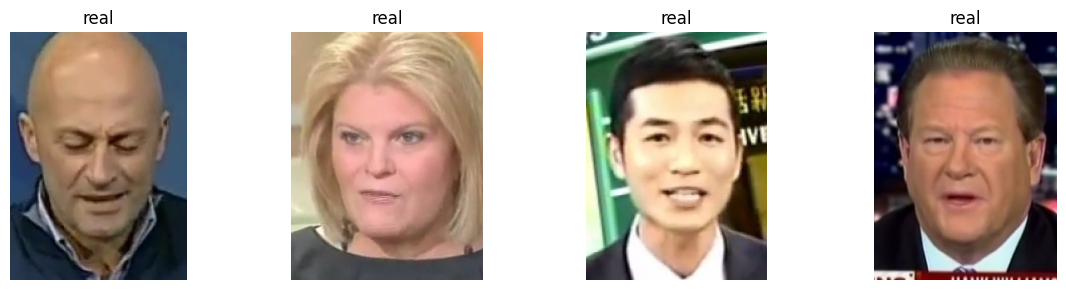

In [10]:
real_crops = len(os.listdir(REAL_OUT))
fake_crops = len(os.listdir(FAKE_OUT))

print(f"Real crops : {real_crops}")
print(f"Fake crops : {fake_crops}")
print(f"Balance    : {real_crops / (real_crops + fake_crops) * 100:.1f}% real")

# Sanity check — display a few crops
import matplotlib.pyplot as plt

samples = os.listdir(REAL_OUT)[:4]
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax, fname in zip(axes, samples):
    img = cv2.imread(os.path.join(REAL_OUT, fname))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis('off')
    ax.set_title("real")
plt.tight_layout()
plt.show()

In [10]:
import cv2
from pathlib import Path

# Check 1: does the real video folder exist and have .mp4 files?
print("REAL_VIDEOS path:", REAL_VIDEOS)
print("Exists:", os.path.exists(REAL_VIDEOS))

mp4s = list(Path(REAL_VIDEOS).glob("*.mp4"))
print("MP4 files found:", len(mp4s))

# Check 2: if mp4s exist, can OpenCV open the first one?
if mp4s:
    cap = cv2.VideoCapture(str(mp4s[0]))
    ret, frame = cap.read()
    print("Can read frame:", ret)
    if ret:
        print("Frame shape:", frame.shape)
    cap.release()
else:
    # Maybe files are not .mp4 — check what extensions exist
    all_files = list(Path(REAL_VIDEOS).glob("*.*"))
    exts = set(f.suffix for f in all_files)
    print("Extensions found instead:", exts)

REAL_VIDEOS path: /root/.cache/kagglehub/datasets/xdxd003/ff-c23/versions/1/original_sequences/youtube/c23/videos
Exists: False
MP4 files found: 0
Extensions found instead: set()
